# DS605 — Lab 5: Machine Learning with Scikit-learn and From Scratch

This notebook implements regression and classification on the UCI Productivity Prediction of Garment Employees dataset.

The workflow follows the assignment requirements:

**Raw Data → Data Inspection → Feature Engineering → Feature Selection → Fixed Train/Test Split → Scikit-learn Models → From-Scratch Models → Evaluation → Comparison → Optimization**

The same target definitions, selected features, train/test samples, and evaluation metrics are reused throughout the comparison.


In [89]:
import numpy as np 
import pandas as pd
import time 


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

RANDOM_STATE = 42
TEST_SIZE = 0.2

## 1. Load the Dataset

Load the Garment Worker Productivity dataset into a Pandas DataFrame and inspect the first few observations to understand its structure.


In [4]:
df = pd.read_csv("garments_worker_productivity.csv")
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


## 2. Dataset Shape

Check the number of observations and variables in the raw dataset before beginning preprocessing.


In [5]:
print("Shape:",df.shape)

Shape: (1197, 15)


## 3. Dataset Information and Data Types

Inspect column names, data types, non-null counts, and memory usage. This helps identify numerical, categorical, and potentially missing-value columns.


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   str    
 1   quarter                1197 non-null   str    
 2   department             1197 non-null   str    
 3   day                    1197 non-null   str    
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: float64(6), 

## 4. Descriptive Statistics

Generate descriptive statistics for all variables to understand their ranges, central tendencies, and categorical distributions.


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,1197,59,1/31/2015,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quarter,1197,5,Quarter1,360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,1197,3,sweing,691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,1197,6,Wednesday,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team,1197.0,NaN,NaN,NaN,6.426901,3.463963,1.0,3.0,6.0,9.0,12.0
targeted_productivity,1197.0,NaN,NaN,NaN,0.729632,0.097891,0.07,0.7,0.75,0.8,0.8
smv,1197.0,NaN,NaN,NaN,15.062172,10.943219,2.9,3.94,15.26,24.26,54.56
wip,691.0,NaN,NaN,NaN,1190.465991,1837.455001,7.0,774.5,1039.0,1252.5,23122.0
over_time,1197.0,NaN,NaN,NaN,4567.460317,3348.823563,0.0,1440.0,3960.0,6960.0,25920.0
incentive,1197.0,NaN,NaN,NaN,38.210526,160.182643,0.0,0.0,0.0,50.0,3600.0


## 5. Missing-Value Analysis

Count missing values in each column. Missing-value patterns are important because the assignment requires explicit handling during preprocessing.


In [8]:
df.isnull().sum()

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

## 6. Duplicate-Row Check

Check whether the dataset contains duplicate observations before modeling.


In [98]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 7. Remove Unnecessary Index Column

Remove an automatically generated index column if it exists. Such a column does not represent a meaningful production feature and should not be used for modeling.


In [97]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

## 8. Create the Classification Target

Create `MeetsTarget` as a binary target:

- `1` when actual productivity is greater than or equal to targeted productivity.
- `0` otherwise.

The original `actual_productivity` column will not be used as an input feature for classification.


In [19]:
df["MeetsTarget"] = (df["actual_productivity"] >= df["targeted_productivity"]).astype(int)

print(df["MeetsTarget"].value_counts())
print(df["MeetsTarget"].value_counts(normalize = True))

MeetsTarget
1    875
0    322
Name: count, dtype: int64
MeetsTarget
1    0.730994
0    0.269006
Name: proportion, dtype: float64


## 9. Date Feature Engineering

Convert the date column to datetime and extract useful temporal features:

- month
- day of month
- day of week

The original date and redundant `day` representation are removed after extracting the required information.


In [99]:
df["date"] = pd.to_datetime(df["date"])

df["date_month"] = df["date"].dt.month
df["date_day"] = df["date"].dt.day
df["date_dayofweek"] = df["date"].dt.dayofweek

df = df.drop(columns=["date", "day"])


## 10. Verify Engineered Features

Display the updated column structure and sample observations to verify that the date transformation and feature engineering were applied correctly.


In [100]:
print(df.columns.tolist())
display(df.head(10))


['quarter', 'department', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity', 'MeetsTarget', 'date_month', 'date_day', 'date_dayofweek']


,quarter,department,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,MeetsTarget,date_month,date_day,date_dayofweek
0,Quarter1,sweing,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725,1,1,1,3
1,Quarter1,finishing,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500,1,1,1,3
2,Quarter1,sweing,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,1,1,1,3
3,Quarter1,sweing,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,1,1,1,3
4,Quarter1,sweing,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382,1,1,1,3
5,Quarter1,sweing,7,0.80,25.90,984.0,6720,38,0.0,0,0,56.0,0.800125,1,1,1,3
6,Quarter1,finishing,2,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.755167,1,1,1,3
7,Quarter1,sweing,3,0.75,28.08,795.0,6900,45,0.0,0,0,57.5,0.753683,1,1,1,3
8,Quarter1,sweing,2,0.75,19.87,733.0,6000,34,0.0,0,0,55.0,0.753098,1,1,1,3
9,Quarter1,sweing,1,0.75,28.08,681.0,6900,45,0.0,0,0,57.5,0.750428,1,1,1,3


## 11. Inspect Target Variables

Inspect the regression target, classification target, and targeted productivity together to verify that the classification target has been constructed correctly.


In [101]:
display(df[["targeted_productivity", "actual_productivity", "MeetsTarget"]].head(50))

,targeted_productivity,actual_productivity,MeetsTarget
0,0.80,0.940725,1
1,0.75,0.886500,1
2,0.80,0.800570,1
3,0.80,0.800570,1
4,0.80,0.800382,1
5,0.80,0.800125,1
6,0.75,0.755167,1
7,0.75,0.753683,1
8,0.75,0.753098,1
9,0.75,0.750428,1


## 12. Define the Regression Dataset

Define `actual_productivity` as the regression target.

The regression feature matrix contains production-related variables while excluding the target columns to prevent target leakage.


In [102]:
# X->production-related-features
# y->actual_productivity

reg_target = "actual_productivity"
X_reg = df.drop(columns = ["actual_productivity", "MeetsTarget"])

y_reg = df[reg_target]

## 13. Define the Classification Dataset

Define `MeetsTarget` as the classification target.

`actual_productivity` is explicitly excluded from the classification feature matrix because it was used to construct the target and would cause target leakage.


In [103]:
# X->production-related-features
# y->MeetsTarget

clas_target = "MeetsTarget"
X_clas = df.drop(columns = ["actual_productivity", "MeetsTarget"])
y_clas = df[clas_target]

## 14. Explicit Feature Selection

Define the numerical and categorical features explicitly rather than relying only on Pandas data types.

This is important because semantic data type matters: `team` is a categorical production identifier even though it is stored as an integer.


In [105]:
numeric_features = [
    "targeted_productivity",
    "smv",
    "wip",
    "over_time",
    "incentive",
    "idle_time",
    "idle_men",
    "no_of_style_change",
    "no_of_workers",
    "date_day"
]

categorical_features = [
    "quarter",
    "department",
    "team",
    "date_month",
    "date_dayofweek"
]

print("Numerical Features: ", numeric_features)
print("Categorical Features :",categorical_features)


Numerical Features:  ['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'date_day']
Categorical Features : ['quarter', 'department', 'team', 'date_month', 'date_dayofweek']


## 15. Final Selected Feature Set

Combine the numerical and categorical feature lists and inspect the final set of features used by both modeling tasks.


In [110]:
selected_features = numeric_features + categorical_features

print("Number of selected features:", len(selected_features))
print("Selected Features:", selected_features)
print("Features missing from selection:", set(X_reg.columns) - set(selected_features))
print("Extra features in selection:", set(selected_features) - set(X_reg.columns))

Number of selected features: 15
Selected Features: ['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'date_day', 'quarter', 'department', 'team', 'date_month', 'date_dayofweek']
Features missing from selection: set()
Extra features in selection: set()


## 16. Assign Features to Regression and Classification Pipelines

Use the same explicitly defined feature structure for both tasks. This ensures that the Scikit-learn and from-scratch implementations operate on the same feature definitions.


In [111]:
reg_numeric_features = numeric_features.copy()
reg_categorical_features = categorical_features.copy()

clas_numeric_features = numeric_features.copy()
clas_categorical_features = categorical_features.copy()

print("Regression Numerical Features:", reg_numeric_features)
print("Regression Categorical Features:", reg_categorical_features)

print("Classification Numerical Features:", clas_numeric_features)
print("Classification Categorical Features:", clas_categorical_features)


Regression Numerical Features: ['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'date_day']
Regression Categorical Features: ['quarter', 'department', 'team', 'date_month', 'date_dayofweek']
Classification Numerical Features: ['targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'date_day']
Classification Categorical Features: ['quarter', 'department', 'team', 'date_month', 'date_dayofweek']


## 17. Create One Fixed Train/Test Split

Create a single reproducible train/test split using a fixed random state.

The same sample indices are reused for every subsequent model so that the comparison between implementations remains fair.


In [112]:
all_indices = np.arange(len(df))

train_indices, test_indices = train_test_split(all_indices, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print("training samples:", len(train_indices))
print("testing samples:", len(test_indices))

training samples: 957
testing samples: 240


## 18. Create Train/Test Datasets

Use the fixed indices to construct training and testing sets for both regression and classification.


In [113]:
# Regression
X_reg_train = X_reg.iloc[train_indices].copy()
X_reg_test = X_reg.iloc[test_indices].copy()

y_reg_train = y_reg.iloc[train_indices].copy()
y_reg_test = y_reg.iloc[test_indices].copy()

# Classification 
X_clas_train = X_clas.iloc[train_indices].copy()
X_clas_test = X_clas.iloc[test_indices].copy()

y_clas_train = y_clas.iloc[train_indices].copy()
y_clas_test = y_clas.iloc[test_indices].copy()

## 19. Verify Split Dimensions

Check the dimensions of the regression and classification train/test sets before model training.


In [114]:
print("Regression:")
print(X_reg_train.shape, X_reg_test.shape)

print("Classification:")
print(X_clas_train.shape, X_clas_test.shape)


Regression:
(957, 15) (240, 15)
Classification:
(957, 15) (240, 15)


## 20. Define Scikit-learn Preprocessing

Build preprocessing pipelines for:

- numerical median imputation
- numerical standardization
- categorical mode imputation
- one-hot encoding

The preprocessing is fitted only on training data through the model pipeline.


In [115]:
numeric_transformer = Pipeline(
    steps = [
        ( 
            "imputer", SimpleImputer(strategy = "median")
        ),
        (
            "scalar", StandardScaler()
        )
    ]
)
categorical_transformer = Pipeline(
    steps =[
        (
            "imputer", SimpleImputer(strategy = "most_frequent")
        ),
        (
            "encoder", OneHotEncoder(handle_unknown = "ignore", sparse_output = False)
        )
    ]
)

## 21. Build the Regression Preprocessor

Create a `ColumnTransformer` that applies the numerical and categorical preprocessing to the selected regression features.


In [116]:
prep_reg = ColumnTransformer(
    transformers = [
        ("numeric", numeric_transformer, reg_numeric_features),
        ("categorical", categorical_transformer, reg_categorical_features)
    ]
)

prep_clas = ColumnTransformer(
    transformers = [
        ("numeric", numeric_transformer, clas_numeric_features),
        ("categorical", categorical_transformer, clas_categorical_features)
    ]
)

## 22. Build the Scikit-learn Linear Regression Pipeline

Combine the regression preprocessor with `LinearRegression` to create a complete end-to-end regression pipeline.


In [117]:
linear_model = Pipeline(
    steps = [
        ("preprocessor", prep_reg),
        ("model", LinearRegression())
    ]
)

## 23. Train Scikit-learn Linear Regression

Train the complete pipeline on the regression training data and measure model training time.


In [118]:
start_time = time.perf_counter()
linear_model.fit(X_reg_train, y_reg_train)
linear_train_time = time.perf_counter() - start_time

## 24. Generate Regression Predictions

Generate predictions for the held-out regression test set and measure prediction time.


In [119]:
start_time = time.perf_counter()
y_reg_pred_sklearn = linear_model.predict(X_reg_test)
linear_predict_time = time.perf_counter() - start_time

## 25. Calculate Regression Metrics

Evaluate the Scikit-learn regression model using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² score


In [120]:
linear_mae = mean_absolute_error(y_reg_test, y_reg_pred_sklearn)
linear_rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_sklearn))
linear_r2 = r2_score(y_reg_test, y_reg_pred_sklearn)

## 26. Scikit-learn Regression Results

Display the regression metrics together with training and prediction time for later comparison with the manual implementation.


In [121]:
print("Sklearn Linear Regression:")
print("MAE :", linear_mae)
print("RMSE: ", linear_rmse)
print("R² :", linear_r2)
print("Train time:", linear_train_time)
print("Predict time:", linear_predict_time)

Sklearn Linear Regression:
MAE : 0.11210716540919724
RMSE:  0.15072396558055715
R² : 0.14442171388786484
Train time: 0.07026840001344681
Predict time: 0.015049300040118396


## 27. Build the Scikit-learn Logistic Regression Pipeline

Combine the classification preprocessing pipeline with `LogisticRegression`.

The classification model predicts `MeetsTarget` without using `actual_productivity` as an input feature.


In [122]:
logistic_model = Pipeline(
    steps = [
        ("preprocessor", prep_clas),
        ("model", LogisticRegression(max_iter=100))
    ]
)

## 28. Train Scikit-learn Logistic Regression

Train the classification pipeline on the fixed training set and record the training time.


In [123]:
start_time = time.perf_counter()
logistic_model.fit(X_clas_train, y_clas_train)
logistic_train_time = time.perf_counter() - start_time

## 29. Generate Classification Predictions

Predict the class labels for the held-out classification test set and record prediction time.


In [124]:
start_time = time.perf_counter()
y_clas_pred_sklearn = logistic_model.predict(X_clas_test)
logistic_predict_time = time.perf_counter() - start_time

## 30. Calculate Classification Metrics

Evaluate the Scikit-learn classifier using:

- Accuracy
- Precision
- Recall
- F1 score


In [125]:
logistic_accuracy = accuracy_score(y_clas_test, y_clas_pred_sklearn)
logistic_precision = precision_score(y_clas_test, y_clas_pred_sklearn, zero_division=0)
logistic_recall = recall_score(y_clas_test, y_clas_pred_sklearn, zero_division=0)
logistic_f1_score = f1_score(y_clas_test, y_clas_pred_sklearn, zero_division=0)

## 31. Scikit-learn Classification Results

Display the classification metrics and timing results for the Scikit-learn implementation.


In [126]:
print("Sklearn Logistic Regression:")
print("Accuracy :", logistic_accuracy)
print("Precison : ", logistic_precision)
print("Recall :", logistic_recall)
print("F1_score :", logistic_f1_score)
print("Train time:", logistic_train_time)
print("Predict time:", logistic_predict_time)

Sklearn Logistic Regression:
Accuracy : 0.7583333333333333
Precison :  0.7902439024390244
Recall : 0.9152542372881356
F1_score : 0.8481675392670157
Train time: 0.053950399975292385
Predict time: 0.01276109996251762


# Part B — From-Scratch Implementation

## 32. Numerical Imputation

Implement numerical missing-value handling manually using training-set medians.

No Scikit-learn preprocessing utilities are used in the from-scratch section.


In [127]:
def fit_numeric_imputer(X_train, numeric_columns):
    medians = {}
    for column in numeric_columns:
        medians[column] = X_train[column].median()
    return medians


def transform_numeric_imputer(X, medians):
    X = X.copy()
    for column, median_value in medians.items():
        X[column] = X[column].fillna(median_value)
    return X

## 33. Categorical Imputation

Implement categorical missing-value handling manually using the most frequent training-set value for each categorical feature.


In [128]:
def fit_categorical_imputer(X_train, categorical_columns):
    modes = {} 
    for column in categorical_columns:
        modes[column] = X_train[column].mode()[0]
    return modes

def transform_categorical_imputer(X, modes):
    X = X.copy()
    for column, mode_value in modes.items():
        X[column] = X[column].fillna(mode_value)
    return X

## 34. Manual Standardization

Calculate the training-set mean and standard deviation for numerical features and use them to standardize the data manually.


In [129]:
def fit_standard_scaler(X_train, numeric_columns):
    means = X_train[numeric_columns].mean()
    stds = X_train[numeric_columns].std(ddof=0)
    stds = stds.replace(0, 1)
    return means, stds

def transform_standard_scaler(X, numeric_columns, means, stds):
    X = X.copy()
    X[numeric_columns] = (X[numeric_columns] - means) / stds
    return X

## 35. Manual One-Hot Encoding

Learn the unique categorical levels from the training data and prepare the mappings required to manually construct one-hot encoded features.


In [130]:
def fit_one_hot_encoder(X_train, categorical_columns):
    categories = {}
    for column in categorical_columns:
        categories[column] = sorted(X_train[column].unique())
    return categories

def transform_one_hot(X, categorical_columns, categories):
    encoded_arrays = []
    feature_names = []
    for column in categorical_columns:
        for category in categories[column]:
            encoded = (X[column] == category).astype(float)
            encoded_arrays.append(encoded.to_numpy().reshape(-1, 1))
            feature_names.append(f"{column}_{category}")
    if len(encoded_arrays) == 0:
        return np.empty((len(X), 0), [])
    return np.hstack(encoded_arrays), feature_names

## 36. Fit the Complete Manual Preprocessor

Combine manual imputation, standardization, and categorical encoding into one preprocessing function.

All preprocessing parameters are learned from the training data only to avoid data leakage.


In [141]:
def fit_manual_preprocessor(
    X_train,
    numerical_features,
    categorical_features
):
    
    # NUMERICAL IMPUTATION
    numeric_medians = fit_numeric_imputer(
        X_train,
        numerical_features
    )

    # CATEGORICAL IMPUTATION
    categorical_modes = fit_categorical_imputer(
        X_train,
        categorical_features
    )

    # APPLY IMPUTATION TO TRAINING DATA
    X_train_processed = transform_numeric_imputer(
        X_train,
        numeric_medians
    )

    X_train_processed = transform_categorical_imputer(
        X_train_processed,
        categorical_modes
    )

    # STANDARDIZATION
    means, stds = fit_standard_scaler(
        X_train_processed,
        numerical_features
    )

    # FIT ONE-HOT ENCODER
    categories = {}

    for column in categorical_features:

        categories[column] = sorted(
            X_train_processed[column]
            .astype(str)
            .unique()
            .tolist()
        )

    return {
        "numeric_medians": numeric_medians,
        "categorical_modes": categorical_modes,
        "means": means,
        "stds": stds,
        "categories": categories
    }

## 37. Transform Data Using Learned Parameters

Apply the learned preprocessing parameters to new data.

The same medians, modes, scaling parameters, and categorical levels learned from training data are reused for the test set.


In [142]:
def transform_manual_preprocessor(X, numeric_columns, categorical_columns, parameters):
    X = X.copy()

    # NUMERICAL IMPUTATION
    X = transform_numeric_imputer(X, parameters["numeric_medians"])

    # Categorical imputation
    X = transform_categorical_imputer(X, parameters["categorical_modes"])
    
    # Numerical scaling
    X = transform_standard_scaler(X, numeric_columns, parameters["means"], parameters["stds"])

    # One-hot encoding
    encoded_matrix, feature_names = transform_one_hot(X, categorical_columns, parameters["categories"])
    
    # Numerical matrix
    numeric_matrix = X[numeric_columns].to_numpy(dtype=float)

    # Combine numerical + categorical
    final_matrix = np.hstack([numeric_matrix,encoded_matrix])
    
    return final_matrix, feature_names

## 38. Prepare Regression Data for the Manual Pipeline

Create the regression training and testing sets using the exact same indices used by the Scikit-learn implementation.


In [143]:
X_reg_train = X_reg.iloc[train_indices].copy()
X_reg_test = X_reg.iloc[test_indices].copy()

y_reg_train = y_reg.iloc[train_indices].to_numpy(dtype=float)
y_reg_test = y_reg.iloc[test_indices].to_numpy(dtype=float)

print("X_reg_train:", X_reg_train.shape)
print("X_reg_test :", X_reg_test.shape)
print("y_reg_train:", y_reg_train.shape)
print("y_reg_test :", y_reg_test.shape)

X_reg_train: (957, 15)
X_reg_test : (240, 15)
y_reg_train: (957,)
y_reg_test : (240,)


## 39. Fit Manual Regression Preprocessor

Learn all preprocessing parameters from the regression training data.


In [144]:
reg_parameters = fit_manual_preprocessor(
    X_reg_train,
    reg_numeric_features,
    reg_categorical_features
)

## 40. Transform Regression Data

Transform the regression training and testing sets into numerical matrices using the manually implemented preprocessing pipeline.


In [145]:
X_reg_train_manual, reg_feature_names = (
    transform_manual_preprocessor(
        X_reg_train,
        reg_numeric_features,
        reg_categorical_features,
        reg_parameters
    )
)

X_reg_test_manual, _ = (
    transform_manual_preprocessor(
        X_reg_test,
        reg_numeric_features,
        reg_categorical_features,
        reg_parameters
    )
)

## 41. Validate Manual Regression Preprocessing

Verify transformed matrix dimensions and confirm that missing values have been removed successfully after manual preprocessing.


In [146]:
print(
    "Manual regression training shape:",
    X_reg_train_manual.shape
)

print(
    "Manual regression testing shape:",
    X_reg_test_manual.shape
)

print(
    "NaN values in training:",
    np.isnan(X_reg_train_manual).sum()
)

print(
    "NaN values in testing:",
    np.isnan(X_reg_test_manual).sum()
)

Manual regression training shape: (957, 39)
Manual regression testing shape: (240, 39)
NaN values in training: 0
NaN values in testing: 0


## 42. Inspect Manual Feature Representation

Combine numerical and encoded categorical feature names to inspect the final feature space used by the manual regression model.


In [149]:
reg_all_feature_names = (
    reg_numeric_features +
    reg_feature_names
)

print("Total features:", len(reg_all_feature_names))

print("Features:")
for i, feature in enumerate(reg_all_feature_names):
    print(i, feature)

Total features: 39
Features:
0 targeted_productivity
1 smv
2 wip
3 over_time
4 incentive
5 idle_time
6 idle_men
7 no_of_style_change
8 no_of_workers
9 date_day
10 quarter_Quarter1
11 quarter_Quarter2
12 quarter_Quarter3
13 quarter_Quarter4
14 quarter_Quarter5
15 department_finishing
16 department_finishing 
17 department_sweing
18 team_1
19 team_10
20 team_11
21 team_12
22 team_2
23 team_3
24 team_4
25 team_5
26 team_6
27 team_7
28 team_8
29 team_9
30 date_month_1
31 date_month_2
32 date_month_3
33 date_dayofweek_0
34 date_dayofweek_1
35 date_dayofweek_2
36 date_dayofweek_3
37 date_dayofweek_5
38 date_dayofweek_6


## 43. Implement Linear Regression from Scratch

Implement Linear Regression using the closed-form normal-equation solution and NumPy.

A pseudo-inverse is used for numerical stability when solving for the regression coefficients.


In [150]:
def fit_linear_regression_manual(X, y):

    # Add intercept column
    X_bias = np.column_stack([
        np.ones(X.shape[0]),
        X
    ])

    # Normal equation
    beta = np.linalg.pinv(X_bias.T @ X_bias) @ (
        X_bias.T @ y
    )

    return beta

## 44. Implement Manual Linear Regression Prediction

Use the learned regression coefficients to generate predictions for new observations.


In [151]:
def predict_linear_regression_manual(X, beta):

    # Add intercept
    X_bias = np.column_stack([
        np.ones(X.shape[0]),
        X
    ])

    return X_bias @ beta

## 45. Train the Manual Linear Regression Model

Fit the from-scratch Linear Regression model and record its training time.


In [153]:
start_time = time.perf_counter()

linear_beta_manual = fit_linear_regression_manual(
    X_reg_train_manual,
    y_reg_train
)

manual_reg_train_time = (
    time.perf_counter() - start_time
)

print(
    f"Manual Linear Regression training time: "
    f"{manual_reg_train_time:.6f} seconds"
)

Manual Linear Regression training time: 0.055059 seconds


## 46. Generate Manual Regression Predictions

Generate predictions on the regression test set and record prediction time.


In [154]:
start_time = time.perf_counter()

y_reg_pred_manual = predict_linear_regression_manual(
    X_reg_test_manual,
    linear_beta_manual
)

manual_reg_prediction_time = (
    time.perf_counter() - start_time
)

print(
    f"Manual Linear Regression prediction time: "
    f"{manual_reg_prediction_time:.6f} seconds"
)

Manual Linear Regression prediction time: 0.000320 seconds


## 47. Implement Regression Metrics from Scratch

Implement MAE, MSE, RMSE, and R² using NumPy without Scikit-learn metric functions.


In [155]:
def mean_absolute_error_manual(y_true, y_pred):

    return np.mean(
        np.abs(y_true - y_pred)
    )


def mean_squared_error_manual(y_true, y_pred):

    return np.mean(
        (y_true - y_pred) ** 2
    )


def root_mean_squared_error_manual(y_true, y_pred):

    return np.sqrt(
        mean_squared_error_manual(
            y_true,
            y_pred
        )
    )


def r2_score_manual(y_true, y_pred):

    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    return 1 - (ss_res / ss_tot)

## 48. Evaluate Manual Linear Regression

Calculate and display the required regression metrics and execution times for the from-scratch implementation.


In [157]:
manual_reg_mae = mean_absolute_error_manual(
    y_reg_test,
    y_reg_pred_manual
)

manual_reg_rmse = root_mean_squared_error_manual(
    y_reg_test,
    y_reg_pred_manual
)

manual_reg_r2 = r2_score_manual(
    y_reg_test,
    y_reg_pred_manual
)


print("MANUAL LINEAR REGRESSION:")


print(f"MAE            : {manual_reg_mae:.6f}")
print(f"RMSE           : {manual_reg_rmse:.6f}")
print(f"R²             : {manual_reg_r2:.6f}")
print(f"Training Time  : {manual_reg_train_time:.6f} sec")
print(f"Prediction Time: {manual_reg_prediction_time:.6f} sec")

MANUAL LINEAR REGRESSION:
MAE            : 0.107553
RMSE           : 0.147340
R²             : 0.182410
Training Time  : 0.055059 sec
Prediction Time: 0.000320 sec


## 49. Prepare Classification Data for the Manual Pipeline

Create the classification training and testing sets using the same fixed indices used in Part A.


In [158]:
X_clas_train = X_clas.iloc[train_indices].copy()
X_clas_test = X_clas.iloc[test_indices].copy()

y_clas_train = y_clas.iloc[train_indices].to_numpy(dtype=float)
y_clas_test = y_clas.iloc[test_indices].to_numpy(dtype=float)

print("X_clas_train:", X_clas_train.shape)
print("X_clas_test :", X_clas_test.shape)
print("y_clas_train:", y_clas_train.shape)
print("y_clas_test :", y_clas_test.shape)

X_clas_train: (957, 15)
X_clas_test : (240, 15)
y_clas_train: (957,)
y_clas_test : (240,)


## 50. Fit Manual Classification Preprocessor

Learn missing-value, scaling, and categorical encoding parameters from the classification training data.


In [159]:
clas_parameters = fit_manual_preprocessor(
    X_clas_train,
    clas_numeric_features,
    clas_categorical_features
)

## 51. Transform Classification Data

Apply the manually learned preprocessing parameters to the classification training and testing data.


In [160]:
X_clas_train_manual, clas_feature_names = (
    transform_manual_preprocessor(
        X_clas_train,
        clas_numeric_features,
        clas_categorical_features,
        clas_parameters
    )
)

X_clas_test_manual, _ = (
    transform_manual_preprocessor(
        X_clas_test,
        clas_numeric_features,
        clas_categorical_features,
        clas_parameters
    )
)

## 52. Validate Manual Classification Preprocessing

Check matrix dimensions and confirm that the manual preprocessing pipeline produces numerical matrices without missing values.


In [161]:
print(
    "Manual classification training shape:",
    X_clas_train_manual.shape
)

print(
    "Manual classification testing shape:",
    X_clas_test_manual.shape
)

print(
    "Training NaNs:",
    np.isnan(X_clas_train_manual).sum()
)

print(
    "Testing NaNs:",
    np.isnan(X_clas_test_manual).sum()
)

Manual classification training shape: (957, 39)
Manual classification testing shape: (240, 39)
Training NaNs: 0
Testing NaNs: 0


## 53. Implement the Sigmoid Function

Implement the sigmoid activation function used by Logistic Regression to convert linear model outputs into probabilities.


In [162]:
def sigmoid(z):

    z = np.clip(z, -500, 500)

    return 1 / (
        1 + np.exp(-z)
    )

## 54. Implement Binary Cross-Entropy Loss

Implement binary cross-entropy loss manually to measure the error of the Logistic Regression probability predictions.


In [163]:
def binary_cross_entropy(y_true, y_prob):

    epsilon = 1e-15

    y_prob = np.clip(
        y_prob,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        y_true * np.log(y_prob)
        +
        (1 - y_true) * np.log(1 - y_prob)
    )

    return loss

## 55. Implement Logistic Regression with Gradient Descent

Implement Logistic Regression from scratch using:

- an intercept term
- vectorized NumPy operations
- sigmoid probabilities
- gradient calculation
- iterative parameter updates
- binary cross-entropy loss tracking


In [164]:
def fit_logistic_regression_manual(
    X,
    y,
    learning_rate=0.01,
    n_iterations=5000
):

    # Add intercept
    X_bias = np.column_stack([
        np.ones(X.shape[0]),
        X
    ])

    # Initialize weights
    weights = np.zeros(
        X_bias.shape[1]
    )

    loss_history = []

    for iteration in range(n_iterations):

        # Forward propagation
        z = X_bias @ weights

        probabilities = sigmoid(z)

        # Error
        error = probabilities - y

        # Gradient
        gradient = (
            X_bias.T @ error
        ) / X_bias.shape[0]

        # Update weights
        weights -= (
            learning_rate * gradient
        )

        # Store loss
        if iteration % 100 == 0:

            loss = binary_cross_entropy(
                y,
                probabilities
            )

            loss_history.append(loss)

    return weights, loss_history

## 56. Predict Logistic Probabilities

Use the learned Logistic Regression parameters to calculate the probability of the positive class.


In [165]:
def predict_logistic_probability_manual(
    X,
    weights
):

    X_bias = np.column_stack([
        np.ones(X.shape[0]),
        X
    ])

    return sigmoid(
        X_bias @ weights
    )

## 57. Convert Probabilities to Class Labels

Apply a threshold of `0.5` to convert predicted probabilities into binary class labels.


In [166]:
def predict_logistic_class_manual(
    X,
    weights,
    threshold=0.5
):

    probabilities = (
        predict_logistic_probability_manual(
            X,
            weights
        )
    )

    return (
        probabilities >= threshold
    ).astype(int)

## 58. Train the Manual Logistic Regression Model

Train the from-scratch Logistic Regression model using vectorized gradient descent and record training time.


In [174]:
start_time = time.perf_counter()

logistic_weights_manual, loss_history = (
    fit_logistic_regression_manual(
        X_clas_train_manual,
        y_clas_train,
        learning_rate=0.01,
        n_iterations=5000
    )
)

manual_clas_train_time = (
    time.perf_counter() - start_time
)

print(
    f"Training time: "
    f"{manual_clas_train_time:.6f} seconds"
)

Training time: 0.243765 seconds


## 59. Generate Manual Classification Predictions

Predict class labels for the held-out classification test set and record prediction time.


In [175]:
start_time = time.perf_counter()

y_clas_pred_manual = (
    predict_logistic_class_manual(
        X_clas_test_manual,
        logistic_weights_manual
    )
)

manual_clas_prediction_time = (
    time.perf_counter() - start_time
)

print(
    f"Prediction time: "
    f"{manual_clas_prediction_time:.6f} seconds"
)

Prediction time: 0.000405 seconds


## 60. Implement Classification Metrics from Scratch

Implement Accuracy, Precision, Recall, and F1 score using NumPy without Scikit-learn metric utilities.


In [176]:
def accuracy_manual(y_true, y_pred):

    return np.mean(
        y_true == y_pred
    )


def precision_manual(y_true, y_pred):

    tp = np.sum(
        (y_true == 1) &
        (y_pred == 1)
    )

    fp = np.sum(
        (y_true == 0) &
        (y_pred == 1)
    )

    if tp + fp == 0:
        return 0.0

    return tp / (tp + fp)


def recall_manual(y_true, y_pred):

    tp = np.sum(
        (y_true == 1) &
        (y_pred == 1)
    )

    fn = np.sum(
        (y_true == 1) &
        (y_pred == 0)
    )

    if tp + fn == 0:
        return 0.0

    return tp / (tp + fn)


def f1_score_manual(y_true, y_pred):

    precision = precision_manual(
        y_true,
        y_pred
    )

    recall = recall_manual(
        y_true,
        y_pred
    )

    if precision + recall == 0:
        return 0.0

    return (
        2 * precision * recall
        / (precision + recall)
    )

## 61. Evaluate Manual Logistic Regression

Calculate and display the required classification metrics and execution times for the from-scratch implementation.


In [177]:
manual_accuracy = accuracy_manual(
    y_clas_test,
    y_clas_pred_manual
)

manual_precision = precision_manual(
    y_clas_test,
    y_clas_pred_manual
)

manual_recall = recall_manual(
    y_clas_test,
    y_clas_pred_manual
)

manual_f1 = f1_score_manual(
    y_clas_test,
    y_clas_pred_manual
)


print("MANUAL LOGISTIC REGRESSION:")

print(f"Accuracy       : {manual_accuracy:.6f}")
print(f"Precision      : {manual_precision:.6f}")
print(f"Recall         : {manual_recall:.6f}")
print(f"F1 Score       : {manual_f1:.6f}")
print(f"Training Time  : {manual_clas_train_time:.6f} sec")
print(f"Prediction Time: {manual_clas_prediction_time:.6f} sec")

MANUAL LOGISTIC REGRESSION:
Accuracy       : 0.750000
Precision      : 0.755459
Recall         : 0.977401
F1 Score       : 0.852217
Training Time  : 0.243765 sec
Prediction Time: 0.000405 sec


## 62. Inspect Training Loss

Compare the initial and final binary cross-entropy loss to verify that the manual Logistic Regression optimization is learning from the training data.


In [178]:
print("Initial loss:", loss_history[0])
print("Final loss  :", loss_history[-1])

Initial loss: 0.6931471805599452
Final loss  : 0.5095333833311461


## 63. Visualize Manual Logistic Regression Convergence

Plot the training loss against iteration number to visualize the optimization process and convergence behavior.


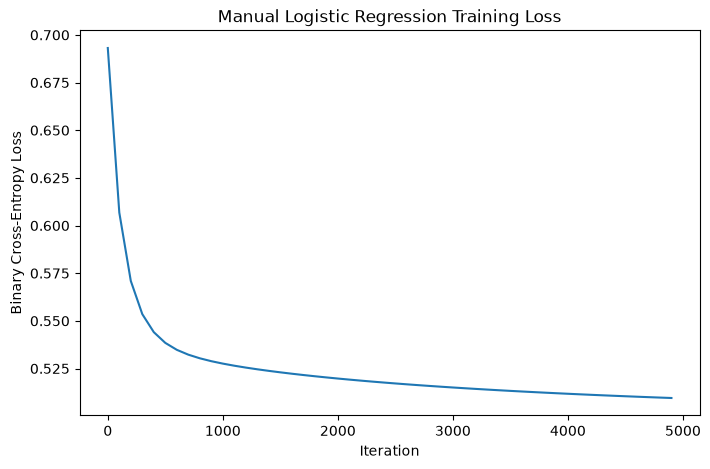

In [179]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(len(loss_history)) * 100,
    loss_history
)

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Manual Logistic Regression Training Loss")

plt.show()

# Part C — Comparison and Optimization

## 64. Compare Regression Implementations

Create a compact comparison table for Scikit-learn and from-scratch Linear Regression using the same test set, metrics, and timing measurements.


In [181]:
regression_comparison = pd.DataFrame({
    
    "Implementation": [
        "Scikit-learn",
        "From Scratch"
    ],
    
    "MAE": [
        linear_mae,
        manual_reg_mae
    ],
    
    "RMSE": [
        linear_rmse,
        manual_reg_rmse
    ],
    
    "R2": [
        linear_r2,
        manual_reg_r2
    ],
    
    "Training Time (s)": [
        linear_train_time,
        manual_reg_train_time
    ],
    
    "Prediction Time (s)": [
        linear_predict_time,
        manual_reg_prediction_time
    ]
})

regression_comparison

,Implementation,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.112107,0.150724,0.144422,0.070268,0.015049
1,From Scratch,0.107553,0.147340,0.182410,0.055059,0.000320


## 65. Format Regression Comparison

Round the regression comparison values for clearer presentation.


In [182]:
regression_comparison.round(6)

,Implementation,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.112107,0.150724,0.144422,0.070268,0.015049
1,From Scratch,0.107553,0.147340,0.182410,0.055059,0.000320


## 66. Compare Classification Implementations

Create a compact comparison table for Scikit-learn and from-scratch Logistic Regression using the same test set, metrics, and timing measurements.


In [185]:
classification_comparison = pd.DataFrame({
    
    "Implementation": [
        "Scikit-learn",
        "From Scratch"
    ],
    
    "Accuracy": [
        logistic_accuracy,
        manual_accuracy
    ],
    
    "Precision": [
        logistic_precision,
        manual_precision
    ],
    
    "Recall": [
        logistic_recall,
        manual_recall
    ],
    
    "F1": [
        logistic_f1_score,
        manual_f1
    ],
    
    "Training Time (s)": [
        logistic_train_time,
        manual_clas_train_time
    ],
    
    "Prediction Time (s)": [
        logistic_predict_time,
        manual_clas_prediction_time
    ]
})

classification_comparison.round(6)

,Implementation,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.758333,0.790244,0.915254,0.848168,0.053950,0.012761
1,From Scratch,0.750000,0.755459,0.977401,0.852217,0.243765,0.000405


## 67. Compare Regression Predictions

Calculate the mean absolute difference between the predictions generated by the Scikit-learn and manual regression models.


In [188]:
reg_prediction_difference = np.mean(
    np.abs(
        y_reg_pred_sklearn -
        y_reg_pred_manual
    )
)

print(
    "Mean absolute difference between "
    "Scikit-learn and manual predictions:",
    reg_prediction_difference
)

Mean absolute difference between Scikit-learn and manual predictions: 0.0417438602395277


## 68. Compare Classification Predictions

Calculate the percentage of test observations for which the Scikit-learn and manual classifiers produce the same predicted class.


In [189]:
classification_agreement = np.mean(
    y_clas_pred_sklearn ==
    y_clas_pred_manual
)

print(
    f"Classification prediction agreement: "
    f"{classification_agreement:.4%}"
)

Classification prediction agreement: 89.1667%


## 69. Optimized Manual Logistic Regression

Improve the baseline manual classifier using vectorized operations, a tuned learning rate, L2 regularization, and convergence-based early stopping.

These changes aim to improve optimization behavior while keeping the implementation fully based on NumPy.


In [190]:
def fit_logistic_regression_optimized(
    X,
    y,
    learning_rate=0.05,
    n_iterations=5000,
    regularization_strength=0.01,
    tolerance=1e-7,
    patience=20
):
    
    # Add intercept
    X_bias = np.column_stack([
        np.ones(X.shape[0]),
        X
    ])

    # Initialize weights
    weights = np.zeros(
        X_bias.shape[1]
    )

    previous_loss = np.inf
    stable_iterations = 0

    loss_history = []

    n_samples = X_bias.shape[0]

    for iteration in range(n_iterations):

        # Forward pass
        z = X_bias @ weights

        probabilities = sigmoid(z)

        # Error
        error = probabilities - y

        # Gradient
        gradient = (
            X_bias.T @ error
        ) / n_samples

        # L2 regularization
        # Do not regularize intercept
        regularization = (
            regularization_strength
            * weights
            / n_samples
        )

        regularization[0] = 0

        gradient += regularization

        # Update weights
        weights -= (
            learning_rate * gradient
        )

        # Calculate loss every 100 iterations
        if iteration % 100 == 0:

            loss = binary_cross_entropy(
                y,
                probabilities
            )

            # L2 penalty excluding intercept
            penalty = (
                regularization_strength
                / (2 * n_samples)
            ) * np.sum(
                weights[1:] ** 2
            )

            loss += penalty

            loss_history.append(loss)

            # Early stopping
            improvement = (
                previous_loss - loss
            )

            if abs(improvement) < tolerance:

                stable_iterations += 1

            else:

                stable_iterations = 0

            if stable_iterations >= patience:

                print(
                    f"Early stopping at iteration "
                    f"{iteration}"
                )

                break

            previous_loss = loss

    return weights, loss_history

## 70. Train the Optimized Manual Classifier

Train the optimized from-scratch Logistic Regression model and record its training time.


In [191]:
start_time = time.perf_counter()

optimized_logistic_weights, optimized_loss_history = (
    fit_logistic_regression_optimized(
        X_clas_train_manual,
        y_clas_train,
        learning_rate=0.05,
        n_iterations=5000,
        regularization_strength=0.01,
        tolerance=1e-7,
        patience=20
    )
)

optimized_clas_train_time = (
    time.perf_counter() - start_time
)

print(
    f"Optimized training time: "
    f"{optimized_clas_train_time:.6f} seconds"
)

Optimized training time: 0.272992 seconds


## 71. Generate Optimized Predictions

Use the optimized model to predict the classification test set and record prediction time.


In [192]:
start_time = time.perf_counter()

y_clas_pred_optimized = (
    predict_logistic_class_manual(
        X_clas_test_manual,
        optimized_logistic_weights
    )
)

optimized_clas_prediction_time = (
    time.perf_counter() - start_time
)

print(
    f"Optimized prediction time: "
    f"{optimized_clas_prediction_time:.6f} seconds"
)

Optimized prediction time: 0.000490 seconds


## 72. Evaluate the Optimized Manual Classifier

Calculate Accuracy, Precision, Recall, and F1 score for the optimized manual implementation.


In [194]:
optimized_accuracy = accuracy_manual(
    y_clas_test,
    y_clas_pred_optimized
)

optimized_precision = precision_manual(
    y_clas_test,
    y_clas_pred_optimized
)

optimized_recall = recall_manual(
    y_clas_test,
    y_clas_pred_optimized
)

optimized_f1 = f1_score_manual(
    y_clas_test,
    y_clas_pred_optimized
)

print("OPTIMIZED MANUAL LOGISTIC REGRESSION:")


print(f"Accuracy       : {optimized_accuracy:.6f}")
print(f"Precision      : {optimized_precision:.6f}")
print(f"Recall         : {optimized_recall:.6f}")
print(f"F1 Score       : {optimized_f1:.6f}")
print(f"Training Time  : {optimized_clas_train_time:.6f} sec")
print(f"Prediction Time: {optimized_clas_prediction_time:.6f} sec")

OPTIMIZED MANUAL LOGISTIC REGRESSION:
Accuracy       : 0.766667
Precision      : 0.776256
Recall         : 0.960452
F1 Score       : 0.858586
Training Time  : 0.272992 sec
Prediction Time: 0.000490 sec


## 73. Baseline vs Optimized vs Scikit-learn

Compare the Scikit-learn model, baseline manual model, and optimized manual model using the same classification metrics and timing measurements.


In [195]:
optimization_comparison = pd.DataFrame({

    "Implementation": [
        "Scikit-learn",
        "Manual Baseline",
        "Manual Optimized"
    ],

    "Accuracy": [
        logistic_accuracy,
        manual_accuracy,
        optimized_accuracy
    ],

    "Precision": [
        logistic_precision,
        manual_precision,
        optimized_precision
    ],

    "Recall": [
        logistic_recall,
        manual_recall,
        optimized_recall
    ],

    "F1": [
        logistic_f1_score,
        manual_f1,
        optimized_f1
    ],

    "Training Time (s)": [
        logistic_train_time,
        manual_clas_train_time,
        optimized_clas_train_time
    ],

    "Prediction Time (s)": [
        logistic_predict_time,
        manual_clas_prediction_time,
        optimized_clas_prediction_time
    ]
})

optimization_comparison.round(6)

,Implementation,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.758333,0.790244,0.915254,0.848168,0.053950,0.012761
1,Manual Baseline,0.750000,0.755459,0.977401,0.852217,0.243765,0.000405
2,Manual Optimized,0.766667,0.776256,0.960452,0.858586,0.272992,0.000490


## 74. Compare Optimization Loss

Compare the initial and final training losses of the baseline and optimized manual Logistic Regression implementations.


In [196]:
print(
    "Baseline initial loss:",
    loss_history[0]
)

print(
    "Baseline final loss:",
    loss_history[-1]
)

print(
    "Optimized initial loss:",
    optimized_loss_history[0]
)

print(
    "Optimized final loss:",
    optimized_loss_history[-1]
)

Baseline initial loss: 0.6931471805599452
Baseline final loss: 0.5095333833311461
Optimized initial loss: 0.6931471816465635
Optimized final loss: 0.5006801599203208


## 75. Visualize Optimized Convergence

Plot the optimized Logistic Regression loss to inspect convergence after learning-rate tuning, regularization, and early stopping.


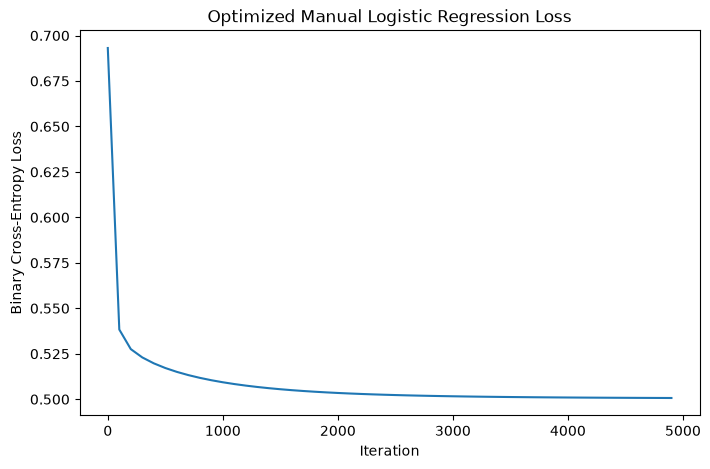

In [197]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(len(optimized_loss_history)) * 100,
    optimized_loss_history
)

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title(
    "Optimized Manual Logistic Regression Loss"
)

plt.show()

## 76. Final Regression Comparison Table

Prepare the final rounded regression comparison table for presentation and reporting.


In [198]:
final_regression_table = regression_comparison.copy()

final_regression_table = (
    final_regression_table.round(6)
)

final_regression_table

,Implementation,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.112107,0.150724,0.144422,0.070268,0.015049
1,From Scratch,0.107553,0.147340,0.182410,0.055059,0.000320


## 77. Final Classification Comparison Table

Prepare the final rounded classification comparison table containing Scikit-learn, baseline manual, and optimized manual results.


In [199]:
final_classification_table = optimization_comparison.copy()

final_classification_table = (
    final_classification_table.round(6)
)

final_classification_table

,Implementation,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.758333,0.790244,0.915254,0.848168,0.053950,0.012761
1,Manual Baseline,0.750000,0.755459,0.977401,0.852217,0.243765,0.000405
2,Manual Optimized,0.766667,0.776256,0.960452,0.858586,0.272992,0.000490


## 78. Runtime Comparison

Summarize the training-time differences between Scikit-learn, the baseline manual implementation, and the optimized manual implementation.


In [200]:
print("RUNTIME COMPARISON")

print(
    f"Scikit-learn training time : "
    f"{logistic_train_time:.6f} sec"
)

print(
    f"Manual training time       : "
    f"{manual_clas_train_time:.6f} sec"
)

print(
    f"Optimized manual time      : "
    f"{optimized_clas_train_time:.6f} sec"
)

RUNTIME COMPARISON
Scikit-learn training time : 0.053950 sec
Manual training time       : 0.243765 sec
Optimized manual time      : 0.272992 sec


## 79. Final Observations

Display the key performance and runtime values that will be used to discuss the effect of the from-scratch implementation and subsequent optimization.


In [202]:
print("FINAL OBSERVATIONS")

print(
    f"Baseline Manual F1: "
    f"{manual_f1:.4f}"
)

print(
    f"Optimized Manual F1: "
    f"{optimized_f1:.4f}"
)

print(
    f"Scikit-learn F1: "
    f"{logistic_f1_score:.4f}"
)

print()

print(
    f"Baseline Manual Training Time: "
    f"{manual_clas_train_time:.6f}s"
)

print(
    f"Optimized Manual Training Time: "
    f"{optimized_clas_train_time:.6f}s"
)

print(
    f"Scikit-learn Training Time: "
    f"{logistic_train_time:.6f}s"
)

FINAL OBSERVATIONS
Baseline Manual F1: 0.8522
Optimized Manual F1: 0.8586
Scikit-learn F1: 0.8482

Baseline Manual Training Time: 0.243765s
Optimized Manual Training Time: 0.272992s
Scikit-learn Training Time: 0.053950s


# Conclusion

This notebook demonstrates the complete machine-learning workflow using both Scikit-learn and manual NumPy/Pandas implementations.

The final comparison evaluates predictive performance, training time, prediction time, and the effect of optimization on the manual Logistic Regression implementation.

The same fixed split, feature definitions, targets, and evaluation metrics are used to keep the comparison reproducible and fair.
